In [1]:
import time
from tqdm import tqdm
from dataclasses import dataclass

In [2]:
import numpy as np
import torch
import torch.nn as nn

In [3]:
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
from stable_baselines3.common.atari_wrappers import FireResetEnv, EpisodicLifeEnv

In [4]:
gym.register_envs(ale_py)

In [5]:
import sys, os

In [6]:
module_path = os.path.abspath("package")
if module_path not in sys.path: sys.path.append(module_path)

In [7]:
from dataclasses import field
from typing import Optional, Any

In [8]:
from package.Samplers import RandomActionSampler, DQNActionSampler, ActionSampler
from package.DQNAgent import DQNAgent
from package.Logger import Logger
from package.TDLoss import TDLoss
from package.Buffer import MemMapDeque
from package.dqn_types import DataClass, ERB
from package.utils import evaluate, play_and_record, show_game, write_params, except_keyboard_interrupt

In [9]:
import matplotlib.pyplot as plt

In [10]:
# ------------------------------------
# About the game: You have 5 lives and get points for breaking the wall.
# Higher bricks cost more than the lower ones.
# There are 4 actions:
# start a game (should be called at the beginning and after each life is lost),
# move left, move right and do nothing.
# There are some common wrappers used for Atari environments.
# ------------------------------------

### Environment Setup

In [11]:
# ------------------------------------
# Environment preprocessing pipeline (Atari / Breakout) for DQN:
# - AtariPreprocessing:
#   standardizes raw frames (e.g., converts to grayscale and resizes to 64×64);
#   disables random no-op starts (noop_max=0) and frame skipping (frame_skip=1) for full control.
# - EpisodicLifeEnv: treats losing a life as an end-of-episode signal, making the penalty more explicit for learning.
# - FireResetEnv: it automatically performs the FIRE action on reset, so the agent doesn’t need a special “start” action.
# - FrameStackObservation: stacks the last 4 frames to provide temporal information (motion, ball velocity/direction).
# ------------------------------------

In [12]:
class RewardOnLifeLoss(gym.Wrapper):
    def __init__(self, env: gym.Env, penalty_weight: float = 1.0):
        super().__init__(env)
        self.lives: int = 0
        self.penalty_weight = penalty_weight

    def step(self, action: int) -> Any:
        obs, reward, terminated, truncated, info = self.env.step(action)
        current_lives = info.get("lives", 0)
        if current_lives < self.lives and self.lives > 0: reward -= self.penalty_weight
        self.lives = current_lives
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs: Any) -> Any:
        obs, info = self.env.reset(**kwargs)
        self.lives = info.get("lives", 0)
        return obs, info

In [13]:
def create_breakout_env(name: str) -> gym.Env:
    environment = gym.make(name, render_mode="rgb_array")
    environment = AtariPreprocessing(environment, noop_max=0, frame_skip=1, terminal_on_life_loss=False, screen_size=84)
    environment = RewardOnLifeLoss(environment, penalty_weight=1.5)
    environment = EpisodicLifeEnv(environment)
    environment = FireResetEnv(environment)
    environment = FrameStackObservation(environment, stack_size=4)
    return environment

In [14]:
env_name = "ALE/Breakout-v5"
envir: gym.Env = create_breakout_env(env_name)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


### Model

In [15]:
#----------------------------
# The model is designed for input images with a size of 4 x 64 x 64.
#----------------------------

In [16]:
# TODO: Поправить модель, она работает с 4 x 64 x 64 а надо на 84 x 84

In [17]:
class ConvBackbone(nn.Sequential):
    """ The convolutional part of a DQN model. """

    def __init__(self, channels_in: int):
        super(ConvBackbone, self).__init__(
            nn.Conv2d(channels_in, 2 ** 4, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(2 ** 4, 2 ** 5, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(2 ** 5, 2 ** 6, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Flatten()
        )

In [18]:
class LinearHead(nn.Sequential):
    """ The linear part of a DQN model. """

    def __init__(self, in_features: int, hidden_size: int, out_features: int):
        super().__init__(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=out_features)
        )

In [19]:
class DuelingDQNHead(nn.Module):
    """ Implements the Dueling DQN logic. """

    def __init__(self, n_actions: int, inp_size: int = 64 * 9 * 9, hidden_size: int = 512):
        super().__init__()
        self.adv_stream = LinearHead(inp_size, hidden_size, n_actions)
        self.value_stream = LinearHead(inp_size, hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Computes Q-values for a given input tensor using advantage and value streams based on the
        dueling DQN architecture: "Q(s,a) = V(s) + A(s,a) - mean (A(s,a))".
        This function splits the input tensor into two separate streams: one for estimating the
        advantage values and another for estimating the state value. The Q-values are then computed
        by combining these streams, where the advantage values are normalized to ensure stability
        and mitigate any dependency on the mean advantage.
        """
        assert x.ndim == 2, x.shape  # (batch_size, n_features)
        advantages = self.adv_stream(x)  # (batch_size, n_actions)
        value = self.value_stream(x)  # (batch_size, 1)
        q_values = value + advantages - advantages.mean(dim=1, keepdim=True)
        return q_values  # (batch_size, n_actions)

In [20]:
class InputScaler(nn.Module):
    """ A module for scaling input tensors by a predefined multiplier. """

    def __init__(self, mult: float):
        super().__init__()
        self.mult = mult

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.mult

In [21]:
class GradScalerFunctional(torch.autograd.Function):
    """ A "torch.autograd.Function" works as "nn.Identity" on forward pass
        and scales the gradient by scale_factor on backward pass. """

    @staticmethod
    def forward(ctx, x, scale_factor):
        ctx.scale_factor = scale_factor
        return x

    @staticmethod
    def backward(ctx, grad_output):  # Ignore profiler warnings !!!
        scale_factor = ctx.scale_factor
        grad_input = grad_output * scale_factor
        return grad_input, None

In [22]:
class GradScaler(nn.Module):
    """ An "nn.Module" encapsulating GradScalerFunctional. """

    def __init__(self, scale_factor: float):
        super().__init__()
        self.scale_factor = scale_factor

    def forward(self, x: torch.Tensor):
        return GradScalerFunctional.apply(x, self.scale_factor)

In [23]:
class DQNetworkDueling(nn.Sequential):
    """
    Represents a Dueling Deep Q-Network (DQN) implemented as a sequential model.
    This class is designed to process input data for training or inference in
    Reinforcement Learning tasks using a Dueling DQN architecture. The input is
    scaled, passed through a convolutional backbone, gradients are scaled,
    and the output is processed by a specific Dueling Q-network head.
    The design follows the Dueling DQN's best practices for gradient scaling and
    output computation.
    """

    def __init__(self, channels_in: int, n_actions: int) -> None:
        # The inputs come from the "uint8" range.
        input_scaler = InputScaler(mult=1 / (2 ** 8 - 1))
        backbone = ConvBackbone(channels_in=channels_in)
        # Dueling DQN suggests do scale the gradient by 1 / sqrt(2).
        grad_scaler = GradScaler(1 / 2 ** 0.5)
        head = DuelingDQNHead(n_actions=n_actions, inp_size=64 * 9 * 9, hidden_size=512)
        super().__init__(input_scaler, backbone, grad_scaler, head)

### Hyperparameters

In [24]:
@dataclass
class OptimParameters(DataClass):
    optimizer: Optional[torch.optim.Optimizer] = None
    lr_scheduler: Optional[torch.optim.lr_scheduler.LRScheduler] = None
    epochs: int = 10000
    batch_size: int = 32
    # Gradient parameters.
    lr: float = 6.25e-05
    optim_eps_start: float = 1.4e-4
    max_grad_norm: float = 10.
    # Update frequency parameters.
    update_freq: int = 4
    target_net_upd_freq: int = 1000
    metricks_upd_freq: int = 100

In [25]:
@dataclass
class EpsilonParameters(DataClass):
    # Epsilon-greedy exploration parameters.
    init_epsilon: float = .5
    final_epsilon: float = 0.1
    decay_steps: int = 10 ** 5

In [26]:
@dataclass
class ModelParameters(DataClass):
    channels_in: int = 4
    hidden_size: int = 512

In [27]:
@dataclass
class HyperParameters(DataClass):
    eps: EpsilonParameters = field(default_factory=EpsilonParameters)
    optim: OptimParameters = field(default_factory=OptimParameters)
    model: ModelParameters = field(default_factory=ModelParameters)
    device: torch.device = torch.device("mps" if torch.mps.is_available() else "cpu")

### Logger

In [28]:
params = HyperParameters()
logger = Logger(directory="results")

### Agent

In [29]:
network = DQNetworkDueling(channels_in=4, n_actions=envir.action_space.n).train(True)
agent = DQNAgent(q_network=network, eps=.5)

In [30]:
last_checkpoint = logger.get_last_checkpoint()
if last_checkpoint is not None: agent.q_network.load_state_dict(last_checkpoint)

In [31]:
tgt_network = DQNetworkDueling(channels_in=params.model.channels_in, n_actions=envir.action_space.n).eval()
tgt_network.load_state_dict(agent.q_network.state_dict())

<All keys matched successfully>

In [32]:
demonstrate: bool = False
if demonstrate:
    print(evaluate(envir, agent, n_games=30, greedy=False))
    print(evaluate(envir, agent, n_games=30, greedy=True))
    # Random samples of actions.
    show_game(env=envir, sampler=RandomActionSampler(envir.action_space), n_frames=2000, freq=0.01)
    # Agent compute actions.
    show_game(env=envir, sampler=DQNActionSampler(agent), n_frames=2000, freq=0.01)

### Replay Buffer

In [33]:
buffer = MemMapDeque("buffer", 10 ** 6, fields=(
    ("obs", np.uint8, envir.observation_space.shape),
    ("action", np.uint8, tuple()),
    ("reward", np.float64, tuple()),
    ("next_obs", np.uint8, envir.observation_space.shape),
    ("done", bool, tuple()),
))

In [34]:
print(buffer)

MemMapDeque(current idx: 0, size: 0, max size: 1000000
  MemMapField(obs, dtype: <class 'numpy.uint8'>, shape: (4, 84, 84))
  MemMapField(action, dtype: <class 'numpy.uint8'>, shape: ())
  MemMapField(reward, dtype: <class 'numpy.float64'>, shape: ())
  MemMapField(next_obs, dtype: <class 'numpy.uint8'>, shape: (4, 84, 84))
  MemMapField(done, dtype: <class 'bool'>, shape: ())
)


In [35]:
%%time
if len(buffer) < 200000:
    _ = play_and_record(
        env=envir,
        sampler=RandomActionSampler(envir.action_space),
        buffer_obj=buffer,
        n_steps=200000,
        show=True
    )
buffer.force_save()

CPU times: user 728 μs, sys: 1.47 ms, total: 2.2 ms
Wall time: 1.64 ms


In [36]:
# Research distributions.
for buffer_field in ["action", "reward", "done"]:
    unique, counts = np.unique(buffer.fields[buffer_field].memmap, return_counts=True)
    print(f"Field: {buffer_field}")
    print(f"Unique: {unique}")
    print(f"Counts: {counts}")
    print("-" * 20)

Field: action
Unique: [0 1 2 3]
Counts: [105450 329669 209170 355711]
--------------------
Field: reward
Unique: [-1.5  0.   1.   4. ]
Counts: [ 24882 963587  11451     80]
--------------------
Field: done
Unique: [False  True]
Counts: [975118  24882]
--------------------


### TD Loss

In [60]:
loss_function = TDLoss(agent=agent, target_agent=tgt_network, gamma=0.9, method="double")

In [61]:
def transform_to_torch(
        obs: np.ndarray,
        actions: np.ndarray | int | float,
        rewards: np.ndarray | int | float,
        next_obs: np.ndarray,
        dones: np.ndarray | bool,
        device: torch.device = torch.device("cpu")
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """ Transforms input data into PyTorch tensors with specified types and device.
        This function converts observations, actions, rewards, next step observations,
        and done flags into PyTorch tensors. It ensures that the data is properly moved
        to the specified device (e.g., CPU or CUDA) and casts the tensors to their
        appropriate data types for further computation. """
    obs_batch = torch.asarray(obs, device=device, dtype=torch.float32)
    act_batch = torch.asarray(actions, device=device, dtype=torch.int64)
    reward_batch = torch.asarray(rewards, device=device, dtype=torch.float32)
    next_obs_batch = torch.asarray(next_obs, device=device, dtype=torch.float)
    is_done_batch = torch.asarray(dones, device=device, dtype=torch.bool)
    return obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch

In [62]:
def linear_decay(init_val: float, final_val: float, cur_step: int, total_steps: int) -> float:
    """ Calculate the linearly decayed value based on the current step and total steps. """
    if cur_step >= total_steps: return final_val
    return (init_val * (total_steps - cur_step) + final_val * cur_step) / total_steps

### Train Loop

In [63]:
### TODO: Проконтролировать - обучается ли модель.

In [65]:
class Trainer:
    def __init__(self, args: HyperParameters, logger_obj: Logger):
        self.args = args
        self.logger = logger_obj

    @except_keyboard_interrupt
    def train(
            self,
            env: gym.Env,
            dqn_agent: DQNAgent,
            target_net: nn.Module,
            buffer_obj: ERB,
            sampler: ActionSampler,
            loss_fn: TDLoss,
            show: bool = True
    ):
        assert self.args.optim.optimizer is not None, "Optimizer is not initialized."
        assert self.args.optim.lr_scheduler is not None, "Learning rate scheduler is not initialized."
        dqn_agent.to(self.args.device), target_net.to(self.args.device)
        progress_bar = tqdm(range(self.args.optim.epochs)) if show else range(self.args.optim.epochs)
        for epoch in progress_bar:
            # ----------------
            assert dqn_agent.training, "DQNAgent is in eval mode."
            assert not target_net.training, "Target network is in train mode."
            self.args.optim.optimizer.zero_grad()
            dqn_agent.eps = linear_decay(
                self.args.eps.init_epsilon, self.args.eps.final_epsilon, epoch, self.args.eps.decay_steps
            )
            _ = play_and_record(env, sampler, buffer_obj, n_steps=self.args.optim.update_freq)
            # ----------------
            # Extract "SARS" from the buffer and transform to torch tensors.
            sample = buffer_obj.sample(self.args.optim.batch_size)
            s, a, r, ns, done = sample["obs"], sample["action"], sample["reward"], sample["next_obs"], sample["done"]
            s, a, r, ns, done = transform_to_torch(s, a, r, ns, done, self.args.device)
            # ----------------
            # Calculate loss, clip gradients and update weights.
            loss = loss_fn(s=s, a=a, r=r, ns=ns, is_done=done)
            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(dqn_agent.parameters(), self.args.optim.max_grad_norm)
            self.args.optim.optimizer.step()
            # self.args.optim.lr_scheduler.step()
            # ----------------
            if epoch % self.args.optim.target_net_upd_freq == 0:
                # Load agent weights into target_network.
                target_net.load_state_dict(dqn_agent.q_network.state_dict())
                self.logger.checkpoint(dqn_agent.q_network.state_dict())
                buffer_obj.force_save()
            # ----------------
            if epoch % self.args.optim.metricks_upd_freq == 0:
                real_epoch = len(self.logger.get_logs()["logs"])
                mean_reward = evaluate(env, dqn_agent, n_games=10, greedy=True, frames_max=20)
                metricks = dict(
                    epoch=real_epoch + 1,
                    loss=loss.data.cpu().item(),
                    grad_norm=grad_norm.cpu().item(),
                    agent_epsilon=dqn_agent.eps,
                    lr=self.args.optim.optimizer.defaults["lr"],
                    mean_reward=mean_reward,
                    time=time.time()
                )
                self.logger.log(**metricks)
            progress_bar.desc = f"Loss: {loss:.8f}; Grad Norm: {grad_norm:.8f}"

In [66]:
params.optim.epochs = 2 * 10 ** 5
params.optim.optimizer = torch.optim.Adam(agent.parameters(), lr=params.optim.lr, eps=params.optim.optim_eps_start)
params.optim.lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    params.optim.optimizer, T_max=params.optim.epochs, eta_min=1e-7
)

In [67]:
logger.set_hyperparams(write_params(params))

In [68]:
trainer_obj = Trainer(args=params, logger_obj=logger)

In [69]:
%%time
trainer_obj.train(
    env=envir,
    dqn_agent=agent,
    target_net=tgt_network,
    buffer_obj=buffer,
    sampler=DQNActionSampler(agent=agent, greedy=False),
    loss_fn=loss_function
)

Loss: 0.00201892; Grad Norm: 0.32972476:  62%|██████▏   | 123668/200000 [1:39:43<1:01:33, 20.67it/s] 

Training interrupted by user.
CPU times: user 42min 43s, sys: 7min 32s, total: 50min 15s
Wall time: 1h 39min 43s


In [70]:
# print(evaluate(envir, agent, n_games=100, greedy=True))
show_game(env=envir, sampler=DQNActionSampler(agent=agent), n_frames=1000, freq=0.01)

In [71]:
def plot(logs: list[dict[str, float]]):
    plt.figure(figsize=[16, 16])
    data: dict[str, list[float]] = {}
    for log in logs:
        for key, value in log.items():
            if key not in data: data[key] = []
            data[key].append(value)

    for num, (key, value) in enumerate(data.items()):
        plt.subplot(10, 1, num + 1)
        plt.plot(value, label=key)
        plt.semilogy()
        plt.legend()
        plt.grid()

    plt.tight_layout()
    plt.show()

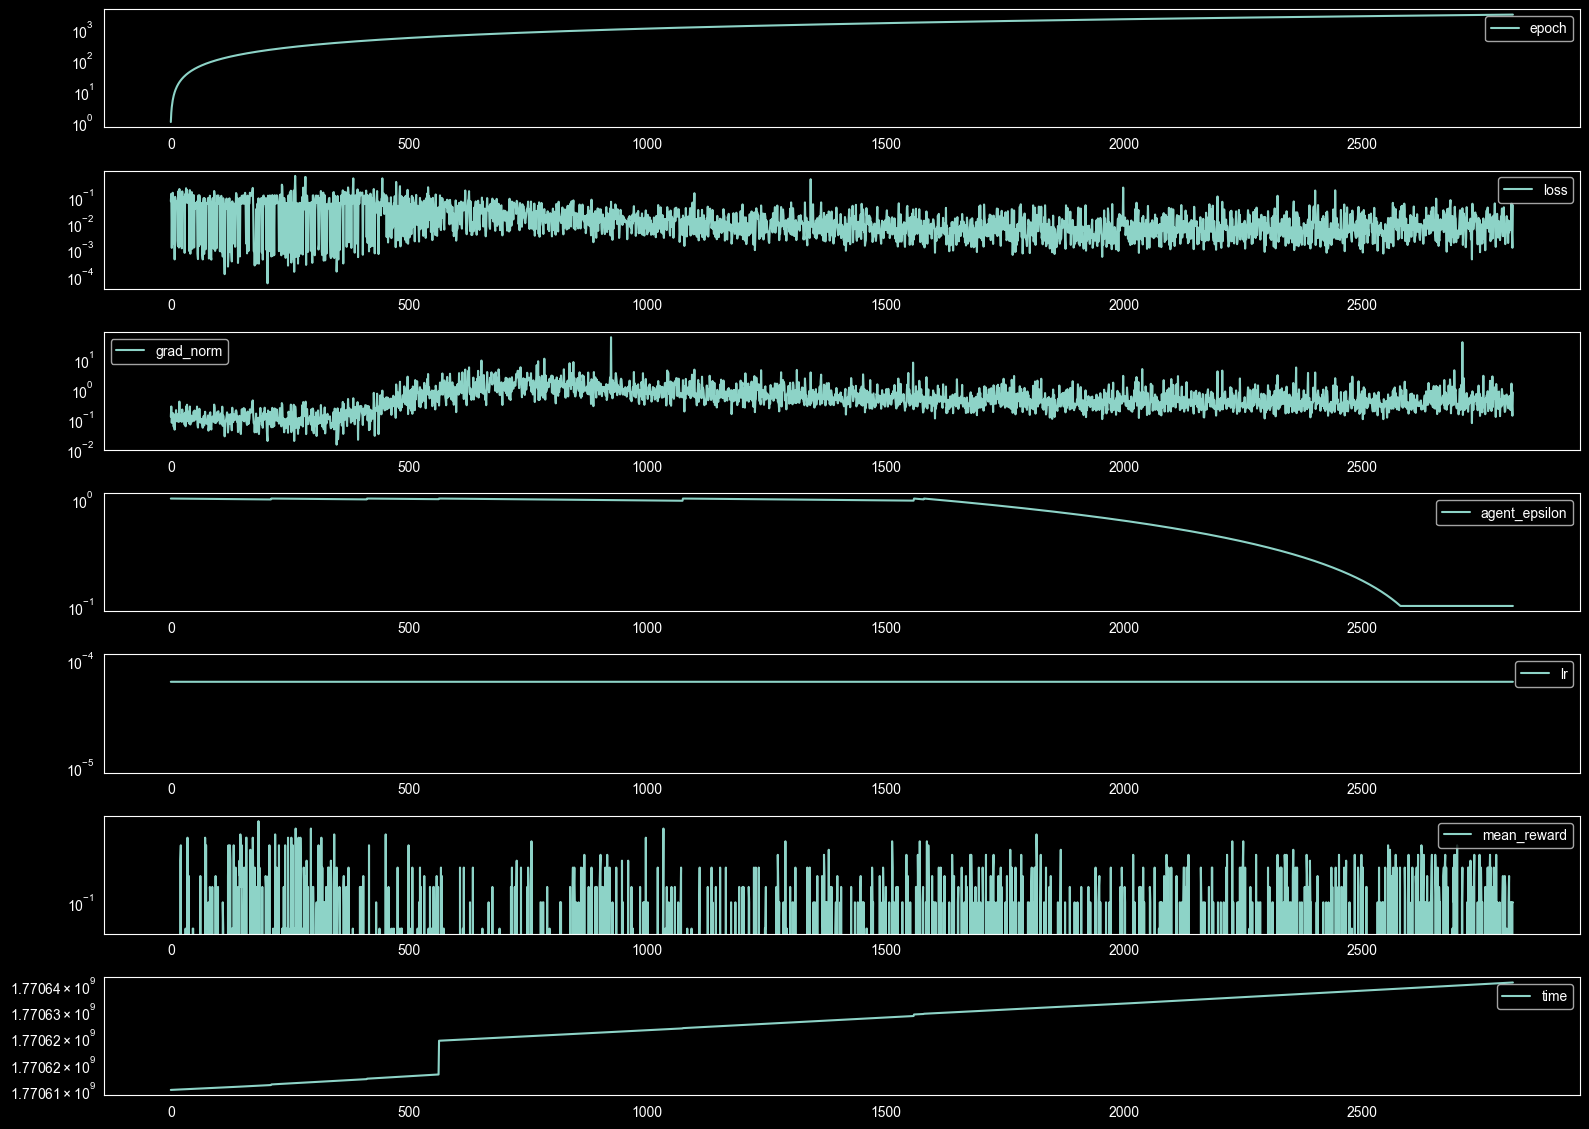

In [72]:
plot(logger.get_logs()["logs"])

- Модель сильно зависит от подбора $\epsilon$ и $\gamma$
- стоило бы рассмотреть модель посложнее, но процесс оптимизации стал бы еще более сложным с точки зрения вычислительных мощностей
- Основная проблема была в том, что модель перестала принимала позицию в крайнем углу экрана и переставала проявлять какие либо движения. Чтобы это исправить был введен штраф за потерю жизни, увеличена $\gamma$, а также пришлось в процессе обучения в ручную подбирать $\epsilon$ исходя из промужуточных результатов.